## WAPIC STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

wapic=pd.read_csv('../stock_data/wapic.csv') ## so it can be small letter. This is cool.
wapic=wapic.drop(columns=['high_price','low_price'])
wapic.rename(columns={'trade_date':'date'},inplace=True)
wapic['date']=pd.to_datetime(wapic['date'])
wapic['month']=wapic['date'].dt.month
wapic['quarter']=wapic['date'].dt.quarter
wapic['year']=wapic['date'].dt.year

wapic

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42820,WAPIC,2017-01-03,0.52,0.52,141936,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43380,WAPIC,2017-01-04,0.51,0.51,425670,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43490,WAPIC,2017-01-05,0.53,0.53,557899,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43600,WAPIC,2017-01-06,0.51,0.51,241364,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43690,WAPIC,2017-01-09,0.52,0.52,856665,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298158,WAPIC,2026-07-13,2.20,2.20,4058668,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298596,WAPIC,2026-07-14,2.27,2.27,799305,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299034,WAPIC,2026-07-15,2.42,2.42,11115011,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299472,WAPIC,2026-07-16,2.42,2.42,2439791,2026-07-16T15:10:03.113936+00:00,7,3,2026


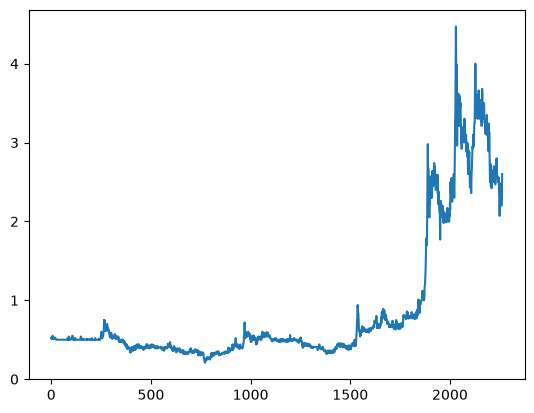

In [2]:
import matplotlib.pyplot as plt

plt.plot(wapic['close_price'])
plt.show()

In [3]:
wapic_end_month_df = (
    wapic
    .sort_values("date")
    .groupby(wapic["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

wapic_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45390,WAPIC,2017-01-31,0.51,0.51,116502,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47212,WAPIC,2017-02-28,0.50,0.50,4031462,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49328,WAPIC,2017-03-31,0.50,0.50,1603,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51155,WAPIC,2017-04-28,0.50,0.50,2254963,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53077,WAPIC,2017-05-31,0.51,0.51,854749,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35397,WAPIC,2026-03-31,3.10,3.10,1012967,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281222,WAPIC,2026-04-30,2.50,2.50,4264339,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284288,WAPIC,2026-05-29,2.47,2.47,1426644,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294216,WAPIC,2026-06-30,2.07,2.07,3586270,2026-06-30T15:10:03.08168+00:00,6,2,2026


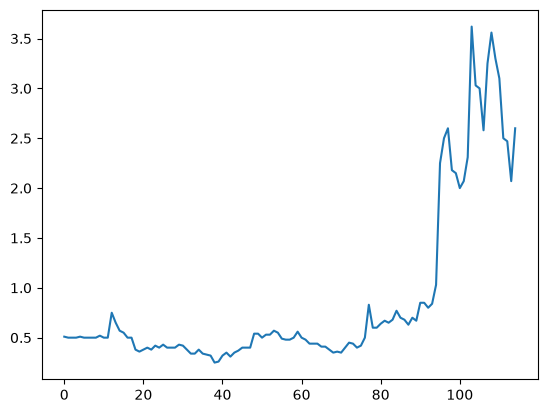

In [4]:
plt.plot(wapic_end_month_df['close_price'])
plt.show()

In [5]:
wapic_end_month_df['returns']=wapic_end_month_df['close_price'].pct_change()*100
wapic_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45390,WAPIC,2017-01-31,0.51,0.51,116502,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47212,WAPIC,2017-02-28,0.50,0.50,4031462,2026-04-08T02:44:45.006295+00:00,2,1,2017,-1.960784
2,49328,WAPIC,2017-03-31,0.50,0.50,1603,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51155,WAPIC,2017-04-28,0.50,0.50,2254963,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53077,WAPIC,2017-05-31,0.51,0.51,854749,2026-04-08T02:52:57.421655+00:00,5,2,2017,2.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35397,WAPIC,2026-03-31,3.10,3.10,1012967,2026-03-31T15:00:02.085058+00:00,3,1,2026,-6.060606
111,281222,WAPIC,2026-04-30,2.50,2.50,4264339,2026-04-30T15:00:02.170664+00:00,4,2,2026,-19.354839
112,284288,WAPIC,2026-05-29,2.47,2.47,1426644,2026-05-29T15:00:02.455558+00:00,5,2,2026,-1.200000
113,294216,WAPIC,2026-06-30,2.07,2.07,3586270,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.194332


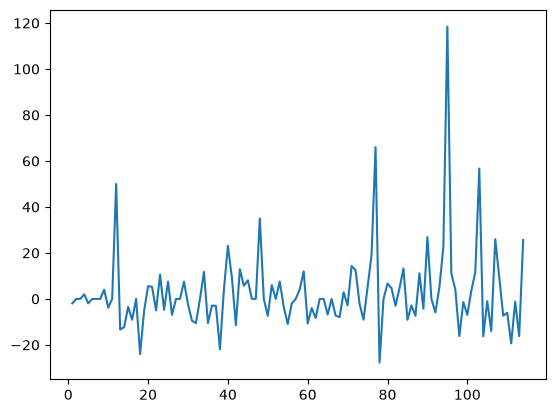

In [6]:
plt.plot(wapic_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(wapic_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.947815864788323), np.float64(2.5616667749935753e-17), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(865.9806830533178))
stationary


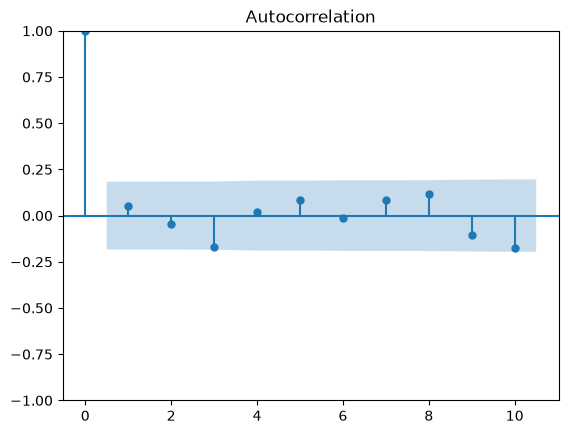

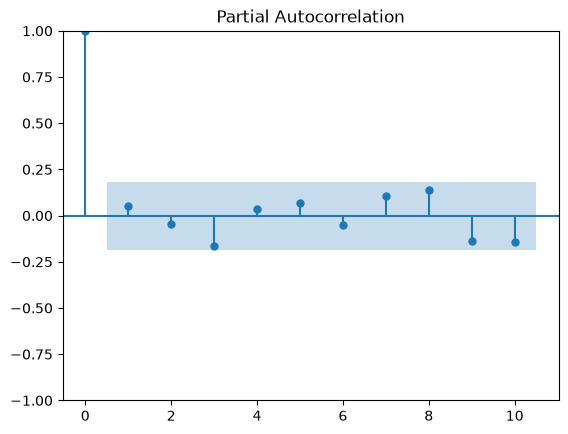

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(wapic_end_month_df['returns'].dropna(), lags=10)
plot_pacf(wapic_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=wapic_end_month_df['close_price'][:-10]
test=wapic_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -41.19995820186461]
[0, 0, 0, 0, 0, 1, -211.10760901406]
[0, 0, 0, 0, 0, 2, -5.727384348039661]
[0, 0, 0, 0, 1, 0, -4.58443478216545]
[0, 0, 0, 0, 1, 1, -3.083310341435011]
[0, 0, 0, 0, 1, 2, -3.1304892169280896]
[0, 0, 0, 0, 2, 0, -5.762071755193549]
[0, 0, 0, 0, 2, 1, -5.051796278260541]
[0, 0, 0, 0, 2, 2, -6.2047447618503995]
[0, 0, 0, 1, 0, 0, -6.442294989173015]
[0, 0, 0, 1, 0, 1, -4.815060724099422]
[0, 0, 0, 1, 0, 2, -2.8044458754729265]
[0, 0, 0, 1, 1, 0, -2.6429974669650043]
[0, 0, 0, 1, 1, 1, -2.5953873805122356]
[0, 0, 0, 1, 1, 2, -2.320138498065175]
[0, 0, 0, 1, 2, 0, -4.713217900286682]
[0, 0, 0, 1, 2, 1, -4.1185514356271185]
[0, 0, 0, 1, 2, 2, -7.957904976535133]
[0, 0, 0, 2, 0, 0, -4.51455164572599]
[0, 0, 0, 2, 0, 1, -4.501764412815147]
[0, 0, 0, 2, 0, 2, -2.889977286943528]
[0, 0, 0, 2, 1, 0, -2.563008848061782]
[0, 0, 0, 2, 1, 1, -2.316443748218536]
[0, 0, 0, 2, 1, 2, -2.3237202438183493]
[0, 0, 0, 2, 2, 0, -5.207120618808774]
[0, 0, 0, 2, 2, 1, -5.

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
1,0,0,0,0,0,1,-211.107609
28,0,0,1,0,0,1,-206.308294
410,1,2,0,0,2,0,-125.867103
653,2,2,0,0,2,0,-121.694097
421,1,2,0,1,2,2,-95.035732
...,...,...,...,...,...,...,...
496,2,0,0,1,0,2,0.116744
307,1,0,2,1,0,2,0.117523
296,1,0,2,0,0,0,0.117901
279,1,0,1,1,0,1,0.120140


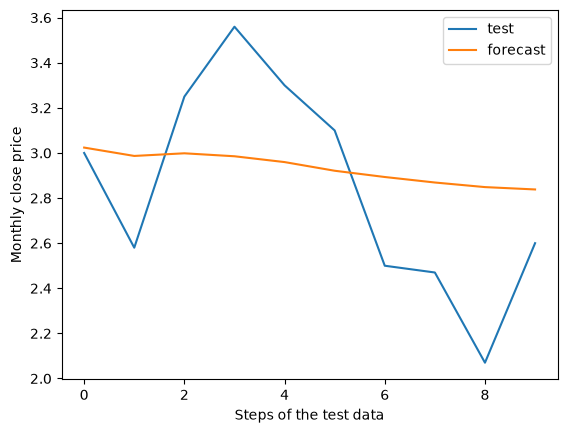

r2_score:  0.14135775706077125
rmse:  0.4104257470749865
description:  count    115.000000
mean       0.872783
std        0.858637
min        0.250000
25%        0.400000
50%        0.500000
75%        0.700000
max        3.620000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=wapic_end_month_df['close_price'][:-10]
y_test=wapic_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,2), 
seasonal_order=(2,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', wapic_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=wapic_end_month_df['returns'].dropna()[:-10]
test=wapic_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0006796411154619264]
[0, 0, 0, 0, 0, 1, -0.06384194686860845]
[0, 0, 0, 0, 0, 2, -0.4181843954407034]
[0, 0, 0, 0, 1, 0, -3.734864809361893]
[0, 0, 0, 0, 1, 1, 0.030874057331302773]
[0, 0, 0, 0, 1, 2, -0.11131192696086378]
[0, 0, 0, 0, 2, 0, -20.483921507378614]
[0, 0, 0, 0, 2, 1, -5.34747582079831]
[0, 0, 0, 0, 2, 2, -1.345519350087233]
[0, 0, 0, 1, 0, 0, -0.08785414587356066]
[0, 0, 0, 1, 0, 1, -0.13014073251976344]
[0, 0, 0, 1, 0, 2, -0.5003991598618542]
[0, 0, 0, 1, 1, 0, 0.12925661324680515]
[0, 0, 0, 1, 1, 1, 0.16017862547624995]
[0, 0, 0, 1, 1, 2, -0.11511271716251259]
[0, 0, 0, 1, 2, 0, -7.0214910767369325]
[0, 0, 0, 1, 2, 1, -1.1378207774234612]
[0, 0, 0, 1, 2, 2, -0.9857693411614108]
[0, 0, 0, 2, 0, 0, 0.11427629446124543]
[0, 0, 0, 2, 0, 1, -0.17930269959803669]
[0, 0, 0, 2, 0, 2, -0.45167910049453774]
[0, 0, 0, 2, 1, 0, -0.6828930867130472]
[0, 0, 0, 2, 1, 1, -0.683055124042601]
[0, 0, 0, 2, 1, 2, -0.6979561674989103]
[0, 0, 0, 2, 2, 0, -2.598909038692

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
699,2,2,1,2,2,0,-1.620963e+07
173,0,2,0,1,0,2,-1.069827e+03
164,0,2,0,0,0,2,-1.069303e+03
175,0,2,0,1,1,1,-1.039611e+03
176,0,2,0,1,1,2,-1.039577e+03
...,...,...,...,...,...,...,...
526,2,0,1,1,1,1,1.570125e-01
13,0,0,0,1,1,1,1.601786e-01
309,1,0,2,1,1,0,2.201634e-01
282,1,0,1,1,1,0,2.441393e-01


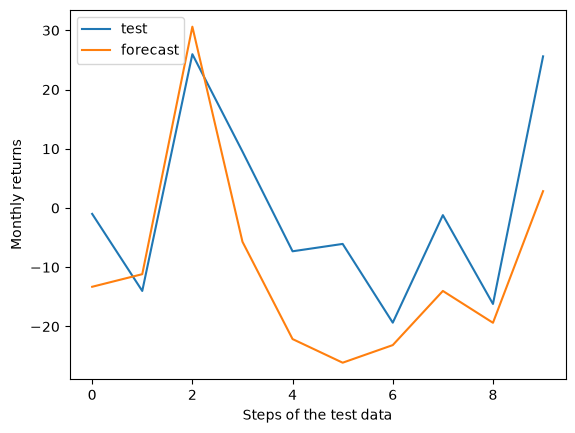

r2_score:  0.25757184202824457
rmse:  13.193806130622646
description:  count    114.000000
mean       2.628686
std       17.714482
min      -27.710843
25%       -6.016043
50%        0.000000
75%        5.928571
max      118.446602
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=wapic_end_month_df['returns'].dropna()[:-10]
y_test=wapic_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,0), 
seasonal_order=(1,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', wapic_end_month_df.returns.dropna().describe())

Better.
